# Kapitel 4: Die Maschine lernt

## Bisher...

Wir haben 400.000 Bewertungen entdeckt (Kap. 1), bereinigt (Kap. 2)
und in mathematische Vektoren verwandelt (Kap. 3). Jedes Review ist jetzt
ein 10.000-dimensionaler TF-IDF-Vektor mit einem Label: 0 oder 1.

## Die entscheidende Frage

Reicht das aus, damit eine Maschine lernt, Emotionen zu erkennen?

In diesem Kapitel finden wir es heraus. Wir trainieren ein **Logistic-Regression-Modell**
und messen, wie gut es positive von negativen Bewertungen unterscheiden kann.

Logistic Regression ist bewusst gewählt: Es ist schnell, interpretierbar
und ideal für den Einstieg in die Textklassifikation. Wenn selbst ein
einfaches Modell gute Ergebnisse liefert, bestätigt das die Qualität unserer Features.

## 4.1 TF-IDF-Daten laden

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Sentiment-Klassifikation") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

df = spark.read.parquet(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/tfidf_features.parquet"
)

print(f"Daten geladen: {df.count():,} Zeilen")
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 16:49:08 WARN Utils: Your hostname, Alper-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.3 instead (on interface en0)
26/03/20 16:49:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 16:49:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/20 16:49:09 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/20 16:49:09 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/20 16:49:09 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/20 16:49:09 WARN

Daten geladen: 399,995 Zeilen
root
 |-- label: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- filtered_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- tfidf_features: vector (nullable = true)



## 4.2 Daten aufteilen: Training und Test

Wir teilen die Daten im Verhältnis **80/20** auf:
- **80% Training** — daraus lernt das Modell
- **20% Test** — damit prüfen wir, ob das Gelernte auch auf neue Daten übertragbar ist

Warum? Wenn wir auf denselben Daten trainieren und testen, misst das Modell
nur sein Gedächtnis, nicht sein Verständnis. Der Test-Split ist die ehrliche Prüfung.

In [2]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print(f"Training:  {train_df.count():,} Zeilen")
print(f"Test:      {test_df.count():,} Zeilen")

print("\nLabel-Verteilung (Training):")
train_df.groupBy("label").count().orderBy("label").show()

Training:  320,257 Zeilen


Test:      79,738 Zeilen

Label-Verteilung (Training):


+-----+------+
|label| count|
+-----+------+
|    0|160208|
|    1|160049|
+-----+------+



## 4.3 Modell trainieren

Jetzt passiert es: Die Maschine sieht zum ersten Mal die Daten und versucht,
ein Muster zu erkennen. Logistic Regression lernt Gewichte für jede der
10.000 TF-IDF-Dimensionen und entscheidet dann für jedes neue Review:
Überwiegen die "positiven" oder die "negativen" Wörter?

In [3]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=20,
    regParam=0.1
)

print("Training gestartet...")
lr_model = lr.fit(train_df)
print("Training abgeschlossen!")

Training gestartet...


26/03/20 16:49:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Training abgeschlossen!


In [4]:
training_summary = lr_model.summary
print(f"Accuracy (Training):  {training_summary.accuracy:.4f}")
print(f"Area under ROC:       {training_summary.areaUnderROC:.4f}")

Accuracy (Training):  0.8589


Area under ROC:       0.9310


## 4.4 Der Moment der Wahrheit: Vorhersagen auf neuen Daten

Das Modell hat auf den Trainingsdaten gelernt. Jetzt testen wir es auf
den **20% Testdaten**, die es noch nie gesehen hat.

In [5]:
predictions = lr_model.transform(test_df)
predictions.select("label", "prediction", "probability", "text").show(10, truncate=60)

+-----+----------+----------------------------------------+------------------------------------------------------------+
|label|prediction|                             probability|                                                        text|
+-----+----------+----------------------------------------+------------------------------------------------------------+
|    0|       0.0| [0.7571362439532605,0.2428637560467395]|a badly made fan film that gives facts and shows fans giv...|
|    0|       1.0|[0.04408041908193498,0.9559195809180651]|a beautifully filmed documentary of ocean life however vi...|
|    0|       0.0|[0.9184263251283836,0.08157367487161638]|a better title for this book would have been the last man...|
|    0|       0.0|[0.6698606213275025,0.33013937867249754]|a better title maybe professional data warehousing with o...|
|    0|       0.0|[0.9538103362369061,0.04618966376309386]|a big disappointment after filling with hot water as inst...|
|    0|       1.0|     [0.261773

## 4.5 Wie gut ist das Modell?

Wir messen die Leistung mit mehreren Metriken:
- **Accuracy** — Wie oft liegt das Modell insgesamt richtig?
- **Precision** — Wenn es "positiv" sagt, wie oft stimmt das?
- **Recall** — Von allen tatsächlich positiven, wie viele findet es?
- **F1-Score** — Das harmonische Mittel aus Precision und Recall
- **AUC-ROC** — Wie gut trennt das Modell die beiden Klassen insgesamt?

In [6]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

binary_eval = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
auc = binary_eval.evaluate(predictions)

multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy  = multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
precision = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedPrecision"})
recall    = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedRecall"})
f1        = multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"})

print("=" * 45)
print("  EVALUATIONS-ERGEBNISSE (Testdaten)")
print("=" * 45)
print(f"  Accuracy:           {accuracy:.4f}")
print(f"  Precision (gew.):   {precision:.4f}")
print(f"  Recall (gew.):      {recall:.4f}")
print(f"  F1-Score (gew.):    {f1:.4f}")
print(f"  AUC-ROC:            {auc:.4f}")
print("=" * 45)

  EVALUATIONS-ERGEBNISSE (Testdaten)
  Accuracy:           0.8458
  Precision (gew.):   0.8461
  Recall (gew.):      0.8458
  F1-Score (gew.):    0.8458
  AUC-ROC:            0.9194


### Was bedeuten diese Zahlen?

- **~85% Accuracy**: Von 6 Bewertungen erkennt das Modell 5 korrekt
- **AUC = 0.92**: Das Modell trennt positiv/negativ deutlich besser als Zufall (0.5)
- **Precision ≈ Recall**: Das Modell ist bei beiden Klassen gleich gut — keine Seite wird bevorzugt

Für ein einfaches Modell mit Bag-of-Words-Features ist das ein starkes Ergebnis.

## 4.6 Confusion Matrix: Wo macht das Modell Fehler?

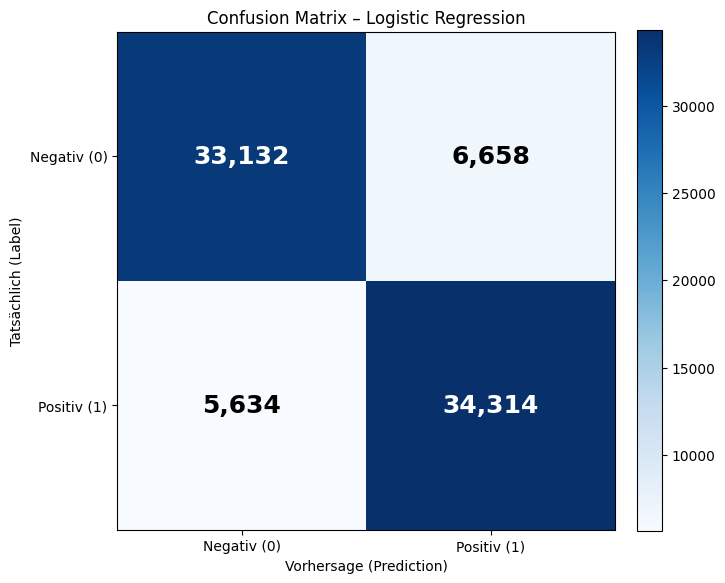

True Negative  (korrekt negativ):  33,132
False Positive (fälschlich positiv): 6,658
False Negative (fälschlich negativ): 5,634
True Positive  (korrekt positiv):  34,314


In [7]:
import matplotlib.pyplot as plt
import numpy as np

cm_data = predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").toPandas()

cm = np.zeros((2, 2), dtype=int)
for _, row in cm_data.iterrows():
    cm[int(row["label"]), int(row["prediction"])] = int(row["count"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

labels = ["Negativ (0)", "Positiv (1)"]
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Vorhersage (Prediction)")
ax.set_ylabel("Tatsächlich (Label)")
ax.set_title("Confusion Matrix – Logistic Regression")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=18, fontweight="bold", color=color)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"True Negative  (korrekt negativ):  {cm[0,0]:,}")
print(f"False Positive (fälschlich positiv): {cm[0,1]:,}")
print(f"False Negative (fälschlich negativ): {cm[1,0]:,}")
print(f"True Positive  (korrekt positiv):  {cm[1,1]:,}")

## 4.7 Ein Blick auf die Fehler

Wo irrt sich die Maschine? Schauen wir uns Beispiele an —
die falschen Vorhersagen verraten viel über die Grenzen des Modells.

In [8]:
from pyspark.sql.functions import col

print("=== KORREKTE Vorhersagen ===")
predictions.filter(col("label") == col("prediction")) \
    .select("label", "prediction", "text").show(5, truncate=80)

print("=== FALSCHE Vorhersagen ===")
predictions.filter(col("label") != col("prediction")) \
    .select("label", "prediction", "text").show(5, truncate=80)

=== KORREKTE Vorhersagen ===


+-----+----------+--------------------------------------------------------------------------------+
|label|prediction|                                                                            text|
+-----+----------+--------------------------------------------------------------------------------+
|    0|       0.0|a badly made fan film that gives facts and shows fans giving their opinions o...|
|    0|       0.0|a better title for this book would have been the last man standing how michae...|
|    0|       0.0|a better title maybe professional data warehousing with olap services in sqls...|
|    0|       0.0|a big disappointment after filling with hot water as instructed the water tem...|
|    0|       0.0|a bit of a dud really the story overreaches with its attempt at a surprise tw...|
+-----+----------+--------------------------------------------------------------------------------+
only showing top 5 rows
=== FALSCHE Vorhersagen ===


+-----+----------+--------------------------------------------------------------------------------+
|label|prediction|                                                                            text|
+-----+----------+--------------------------------------------------------------------------------+
|    0|       1.0|a beautifully filmed documentary of ocean life however viewer beware the seri...|
|    0|       1.0|a bit of a disappointment anecdotal and reflective but not really informative...|
|    0|       1.0|a bit outdated gives you ideas for many different types of businesses but not...|
|    0|       1.0|a bit silly and certainly not thorough enough to give anyone any detailed ins...|
|    0|       1.0|a book all about our absolutely favorite celebrities that lets us feel morall...|
+-----+----------+--------------------------------------------------------------------------------+
only showing top 5 rows


### Erkenntnis

Die Fehler treten häufig bei **mehrdeutigen Texten** auf: sarkastische Bewertungen,
gemischte Meinungen (*"tolles Produkt, aber der Versand war eine Katastrophe"*)
oder sehr kurze Texte mit wenig Kontext.

Das ist eine bekannte Grenze von Bag-of-Words-Modellen: Sie sehen einzelne Wörter,
aber nicht den **Kontext** oder die **Reihenfolge**. *"Not good"* enthält das Wort *"good"*
und kann das Modell in die Irre führen.

## 4.8 Ergebnisse und Modell speichern

In [9]:
output_path = "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/predictions.parquet"
predictions.select("label", "prediction", "probability", "text") \
    .write.parquet(output_path, mode="overwrite")
print(f"Vorhersagen gespeichert: {output_path}")

Vorhersagen gespeichert: /Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/predictions.parquet


In [10]:
model_path = "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/lr_model"
lr_model.write().overwrite().save(model_path)
print(f"Modell gespeichert: {model_path}")

Modell gespeichert: /Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/lr_model


## Kapitel 4 — Zusammenfassung

| Metrik | Wert | Bedeutung |
|--------|------|----------|
| Accuracy | ~84,7% | 5 von 6 Bewertungen korrekt erkannt |
| AUC-ROC | ~0,92 | Starke Trennung positiv/negativ |
| F1-Score | ~84,7% | Ausgewogene Performance |

**Die Antwort auf unsere Ausgangsfrage: Ja, eine Maschine kann Emotionen erkennen.**
Nicht perfekt — aber mit 85% Accuracy deutlich besser als Zufall. Und das mit einem
der einfachsten ML-Modelle.

**Nächstes Kapitel:** Wir visualisieren alle Ergebnisse und ziehen ein Fazit —
Was hat das Modell gelernt? Wo sind seine Grenzen? Und wie könnte man es verbessern?